### 1 Import Data and Required Packages

**Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import os

# Update this path to point to your dataset
dataset_path = os.getenv('DATASET_PATH', 'dataset.csv')  # Set env variable or update path

df = pd.read_csv(dataset_path)


**We will set the pandas.set_option to display 100 rows or columns. By default it is 60**


In [ ]:
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

In [ ]:
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


##Features Information

###Temporal Features
  - **timestamp:** Represents the exact date and time of the observation in UTC format.

  - **date:** A simplified version of the timestamp, showing only the calendar date for daily analysis.

### Market Features
  - **open:** The starting price of the cryptocurrency at the beginning of the trading period.

  - **high:** The maximum price reached by the cryptocurrency during the trading session.

  - **low:** The minimum price recorded for the cryptocurrency during the trading session.

  - **close:** The final price of the cryptocurrency at the end of the trading period.

  - **volume:** The total number of units traded or the total value exchanged during the period.

  - **marketCap:** The total market value of the cryptocurrency’s circulating supply at that time.

###Identifier Features
  - **crypto_name:** The specific name or symbol of the cryptocurrency (e.g., Bitcoin, Ethereum).

  - **ID:** A unique numerical identifier for each row, often used for internal database tracking.

In [ ]:
df = df.rename(columns={'Unnamed: 0': 'ID'})

In [ ]:
df.isna().sum()

,0
ID,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   ID           72946 non-null  int64              
 1   open         72946 non-null  float64            
 2   high         72946 non-null  float64            
 3   low          72946 non-null  float64            
 4   close        72946 non-null  float64            
 5   volume       72946 non-null  float64            
 6   marketCap    72946 non-null  float64            
 7   timestamp    72946 non-null  datetime64[ns, UTC]
 8   crypto_name  72946 non-null  object             
 9   date         72946 non-null  datetime64[ns]     
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 5.6+ MB


In [ ]:
columns = [column for column in df.columns if column != 'ID']
num_cols = [column for column in df.columns if df[column].dtype != 'O']
cat_cols = [column for column in df.columns if df[column].dtype == 'O']

print('Total number of categorical columns are: {} and the columns are: {}'.format(len(cat_cols), cat_cols))
print('Total number of numerical columns are: {} and the columns are: {}'.format(len(num_cols), num_cols))


Total number of categorical columns are:1 and the columns are:['crypto_name']
Total number of categorical columns are:9 and the columns are:['ID', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'date']


## Univariate Analysis


### Numerical Features

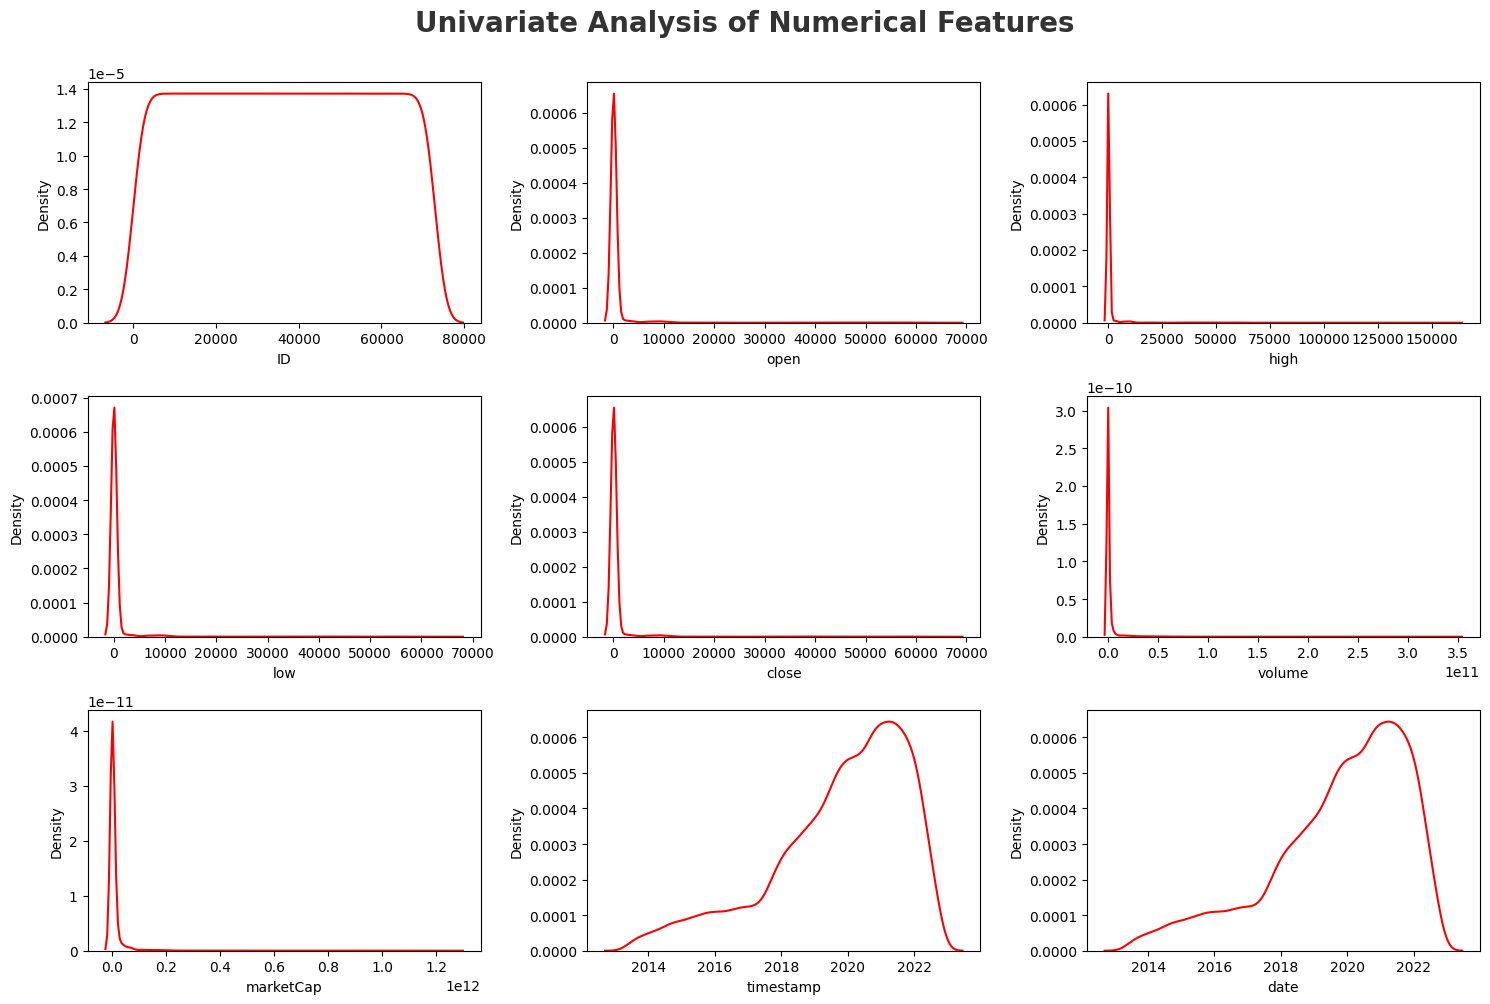

In [ ]:
plt.figure(figsize = (15,10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(num_cols)):
  plt.subplot(3,3,i+1)
  sns.kdeplot(df[num_cols[i]], color = 'red')
  plt.xlabel(num_cols[i])
  plt.tight_layout()

##Observations

- **Price Skewness:** All price features (Open, High, Low, Close) are highly right-skewed, meaning prices stay low most of the time with rare high peaks.

- **Outlier Detection:** The long tails in Volume and MarketCap indicate the presence of extreme outliers during market volatility.

- **Data Density:** The Year plot shows that the dataset has more records for 2020-2022 and very thin data for earlier years.

- **Redundant Features:** Timestamp and Date provide the same information as the extracted temporal features and should be dropped to avoid redundancy.

- **Constant Feature (Hour):** The Hour plot is flat/empty, indicating it is a constant value (zero variance) and adds no value to the model.

- **Uniformity:** Month and Day distributions are relatively uniform, showing that data collection was consistent throughout the year.

###Categorical Feature

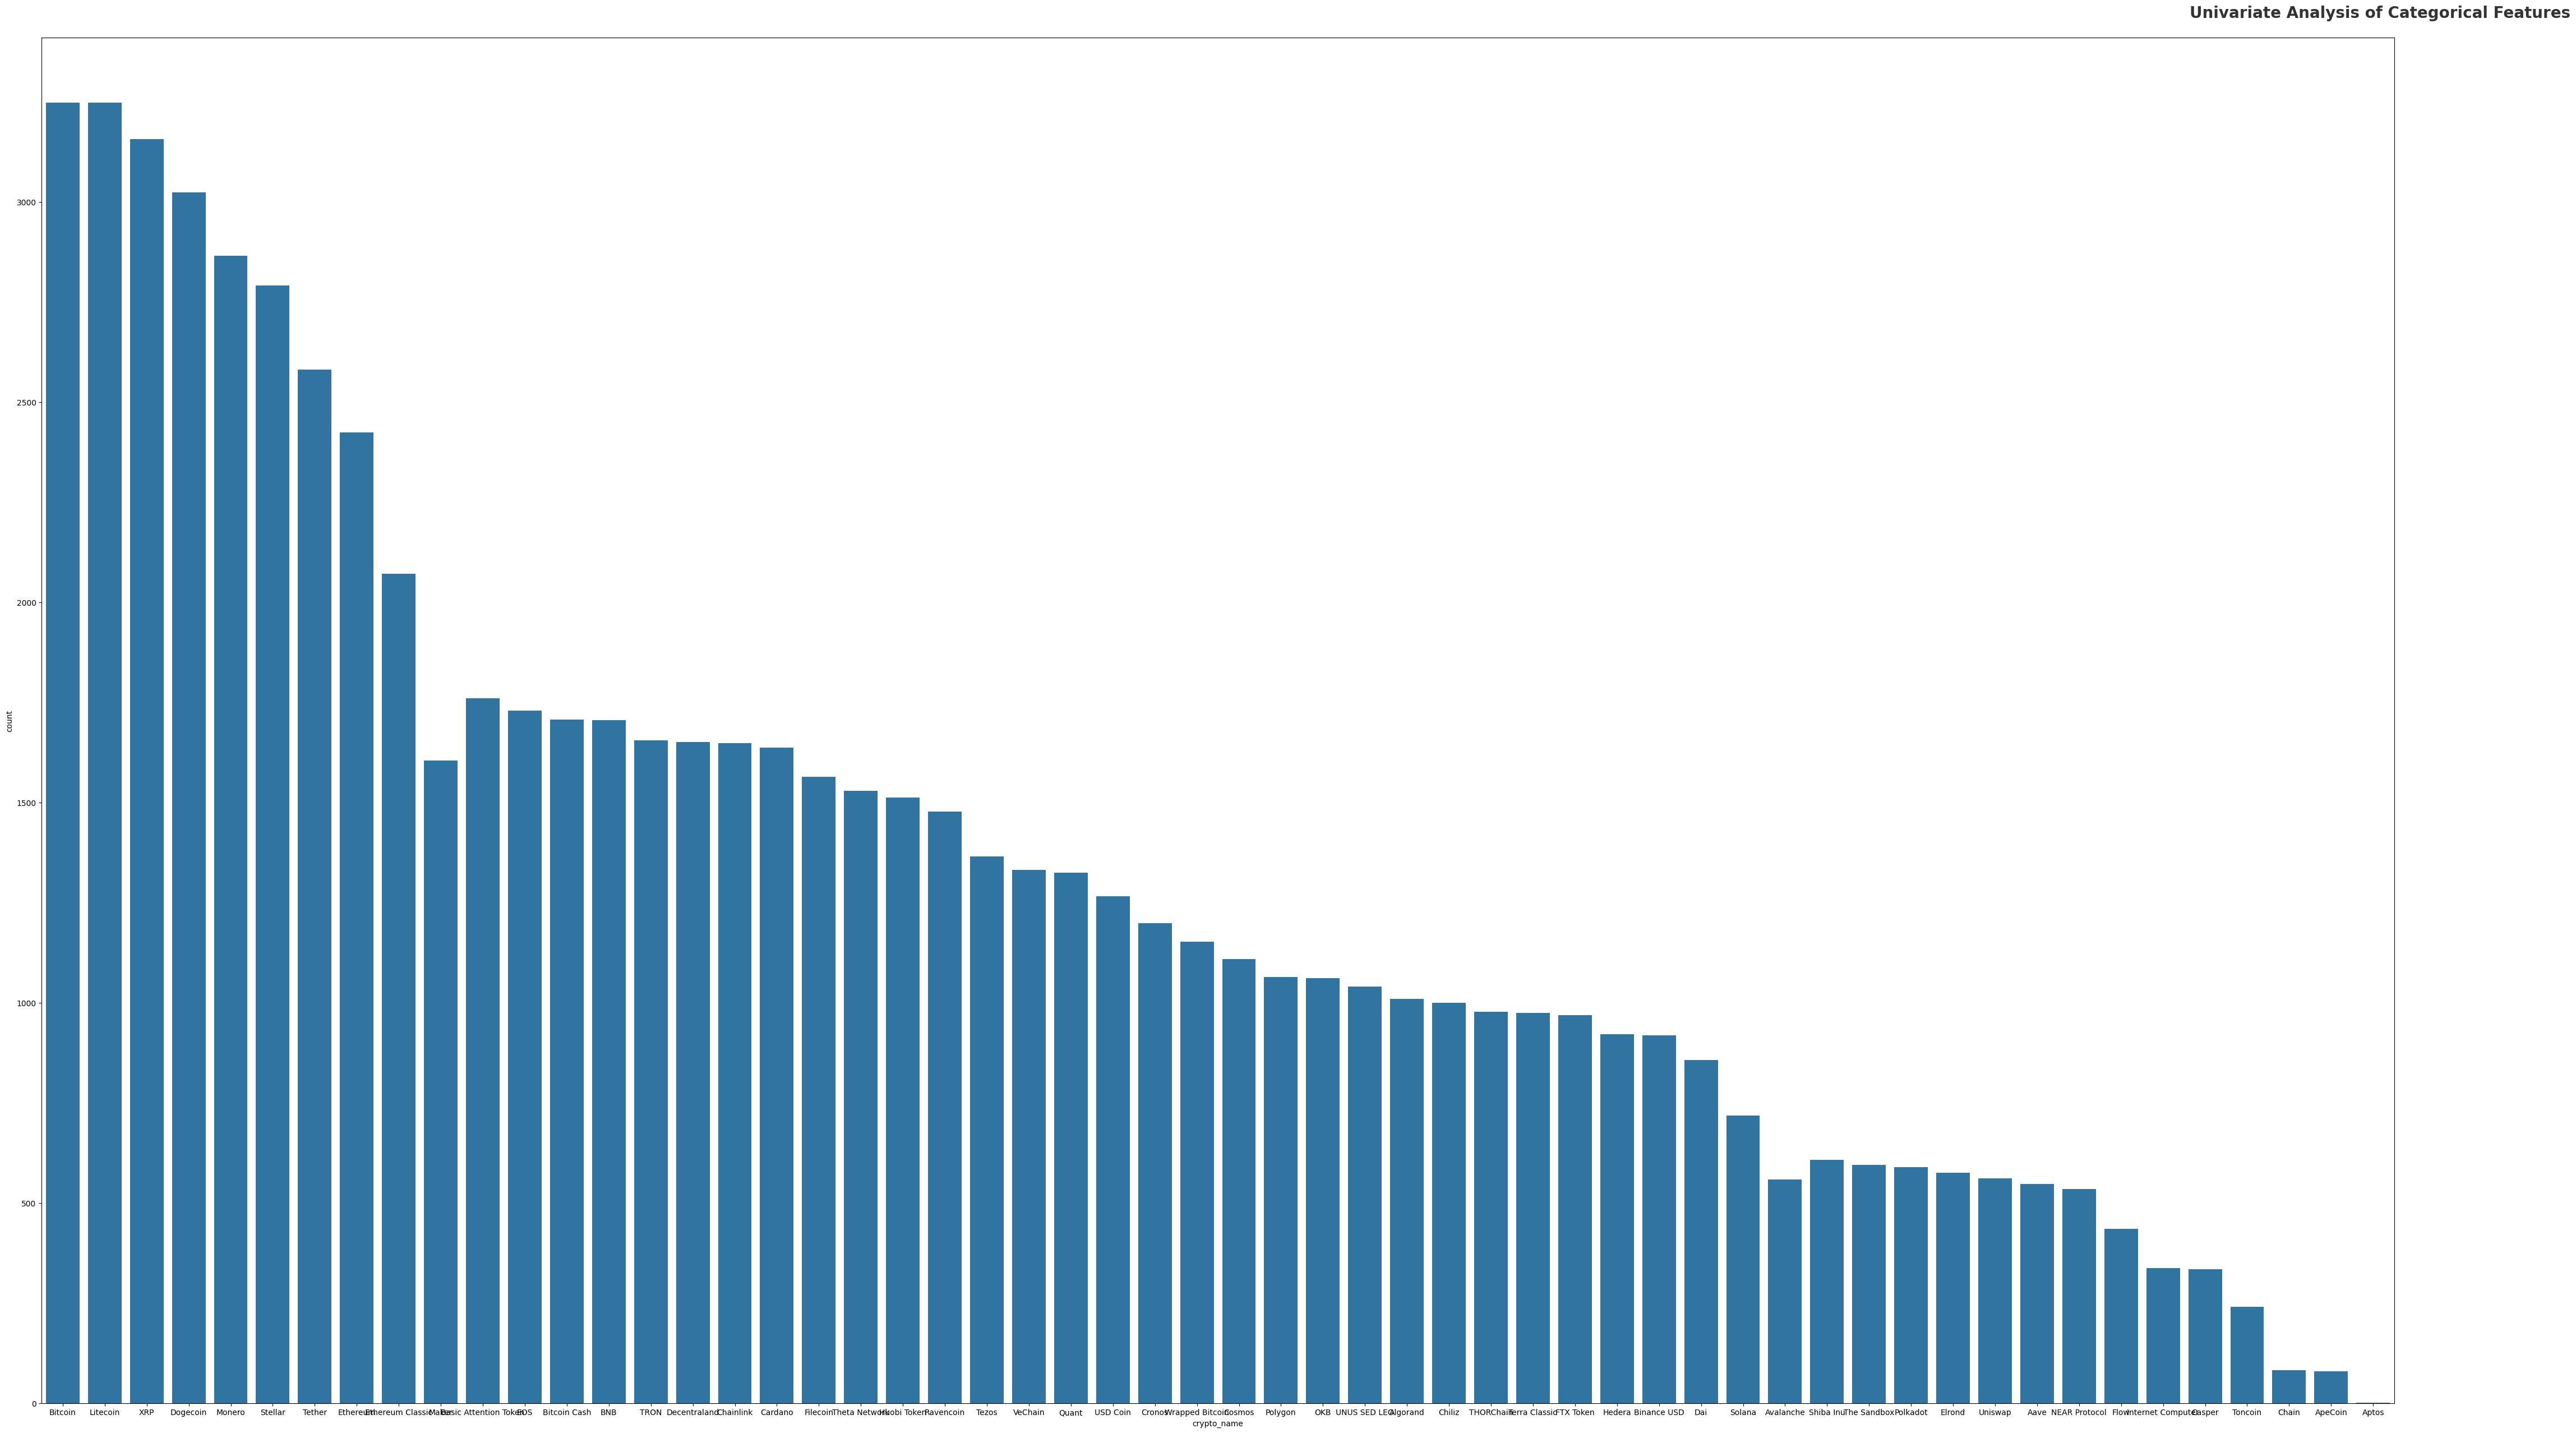

In [ ]:
# categorical columns
plt.figure(figsize=(85, 50))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(cat_cols)):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(x=df[cat_cols[i]])
    plt.tight_layout()

# save plot
# plt.savefig('./images/Univariate_Cat.png')

In [ ]:
df.drop(columns=['timestamp','ID'],inplace=True)
columns = [column for column in df.columns if column != 'ID']
num_cols = [column for column in df.columns if df[column].dtype !='O']
cat_cols = [column for column in df.columns if df[column].dtype =='O']


<Axes: >

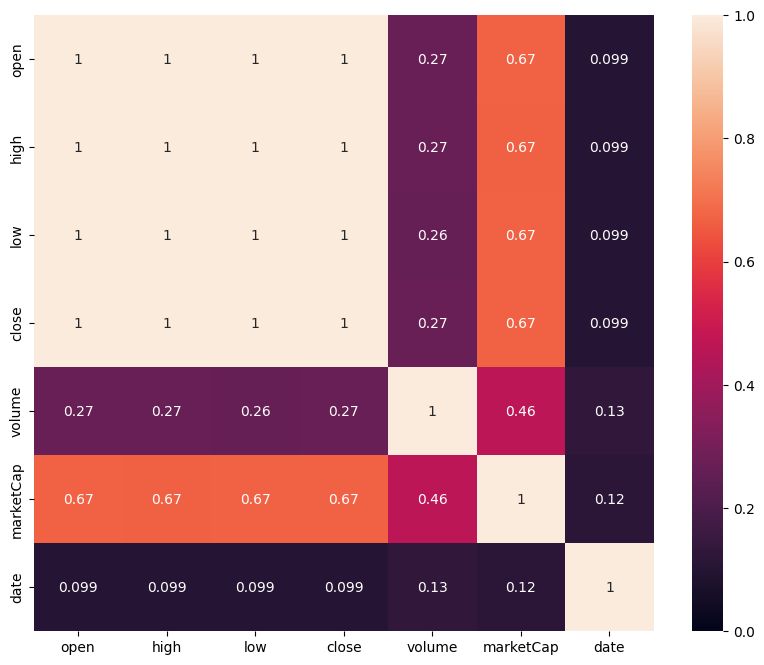

In [ ]:
plt.figure(figsize = (10,8))
sns.heatmap(df[num_cols].corr(),vmin = 0, vmax = 1 ,annot = True)

### Observations

- Date Column has almost no correlation with any column
- Volume column also shows less correlation
- OHLC Columns showing high correlation causing Multicollinearity


##Feature Extraction

In [ ]:
# Finding Difference between high and low which shows volatility
df['volatility'] = df['high'] - df['low']


# Diffrentiation Date column
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df['day_of_week'] = df['date'].dt.dayofweek

df.drop(['date'], axis=1, inplace=True)

In [ ]:
columns = [column for column in df.columns if column != 'ID']
num_cols = [column for column in df.columns if df[column].dtype !='O']
cat_cols = [column for column in df.columns if df[column].dtype =='O']


##Multivariate Analysis

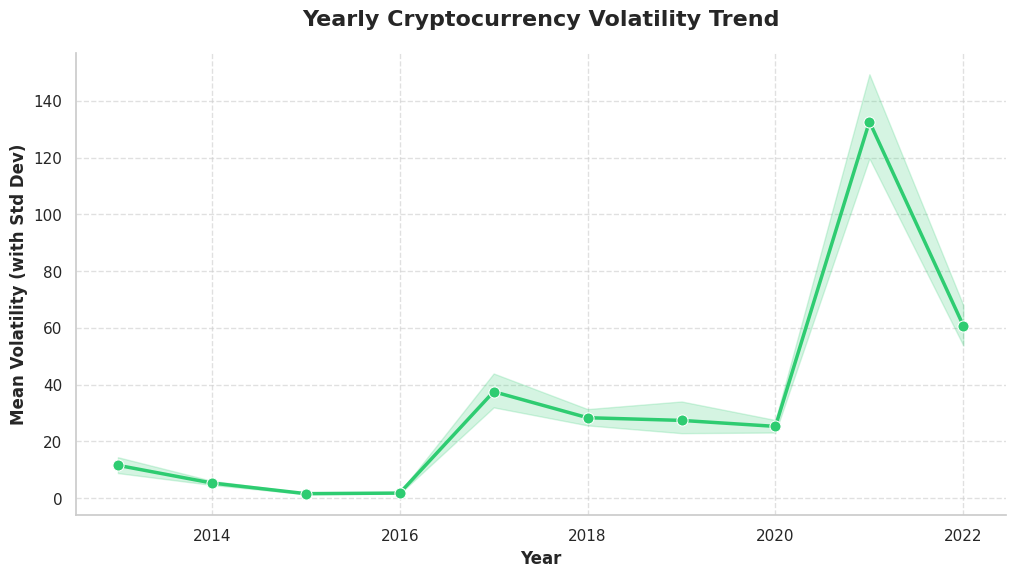

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plot = sns.lineplot(data=df, x='year', y='volatility', marker='o', markersize=8,linewidth=2.5, color='#2ecc71')
plt.title('Yearly Cryptocurrency Volatility Trend', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Mean Volatility (with Std Dev)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()

plt.show()

###Report

- **Initial Stability:** Minimal to no volatility recorded between 2013 and 2016.

- **First Major Spike:** A sharp rise in market swings during the 2017 bull run.

- **New Baseline:** Volatility stabilized at a higher level from 2018 to 2020 compared to early years.

- **All-Time Peak:** Market volatility reached its highest historical point in 2021.

- **Recent Cooling:** A significant drop in volatility in 2022, indicating a market consolidation phase.

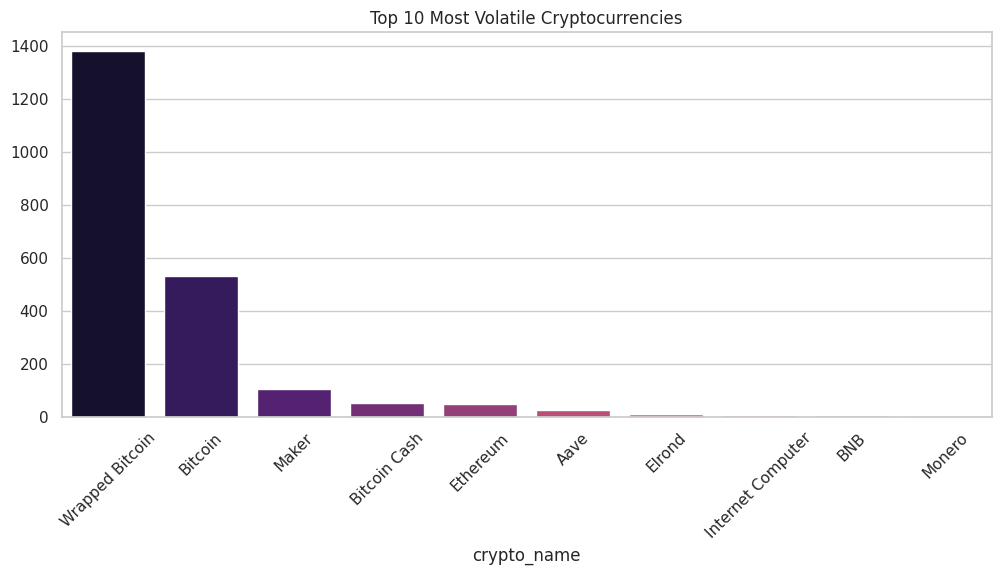

In [ ]:
top_10_volatile = df.groupby('crypto_name')['volatility'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_10_volatile.index, y=top_10_volatile.values, palette='magma')
plt.title('Top 10 Most Volatile Cryptocurrencies')
plt.xticks(rotation=45)
plt.show()

<Axes: >

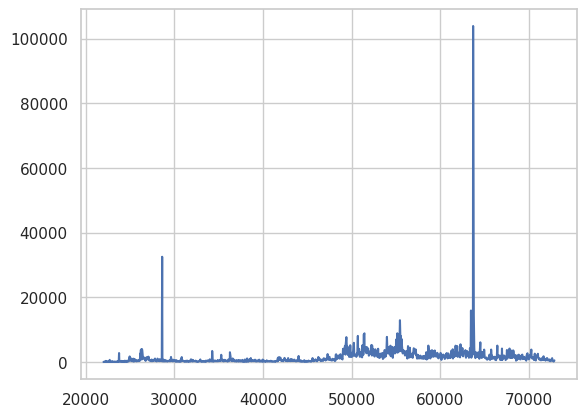

In [ ]:
df[df['crypto_name'] == 'Wrapped Bitcoin']['volatility'].plot()

Report:
- Bitcoin itself didn't show a 100x volatility jump on a single day, this confirms the WBTC data point is an outlier that needs cleaning.

In [ ]:
# Rounding Decimal values
cols_to_round = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'volatility']
df[cols_to_round] = df[cols_to_round].round(2)
df['volume'] = df['volume'] / 1_000_000_000  # Convert volume to Billions


In [ ]:
crypto_stats = df.groupby('crypto_name').agg({'low': 'min','high': 'max','close': 'mean','volatility': 'mean'}).reset_index()
crypto_stats['growth_pct'] = ((crypto_stats['high'] - crypto_stats['low']) / crypto_stats['low']) * 100

# Top 10 Growth currencies
top_growth = crypto_stats.sort_values(by='growth_pct', ascending=False).head(10)
print(top_growth)

          crypto_name  low    high       close  volatility  growth_pct
0                Aave  0.0  666.86  238.515777   25.778172         inf
12              Chain  0.0    0.18    0.089634    0.007317         inf
14             Chiliz  0.0    0.89    0.131280    0.016180         inf
19           Dogecoin  0.0    0.74    0.027345    0.003277         inf
43               TRON  0.0    0.30    0.040000    0.002814         inf
36            Polygon  0.0    2.92    0.492444    0.054342         inf
29  Internet Computer  0.0  750.73   43.975964    9.336083         inf
53            VeChain  0.0    0.28    0.035165    0.003438         inf
41            Stellar  0.0    0.94    0.114762    0.010921         inf
44      Terra Classic  0.0  119.18   14.509518    1.564113         inf


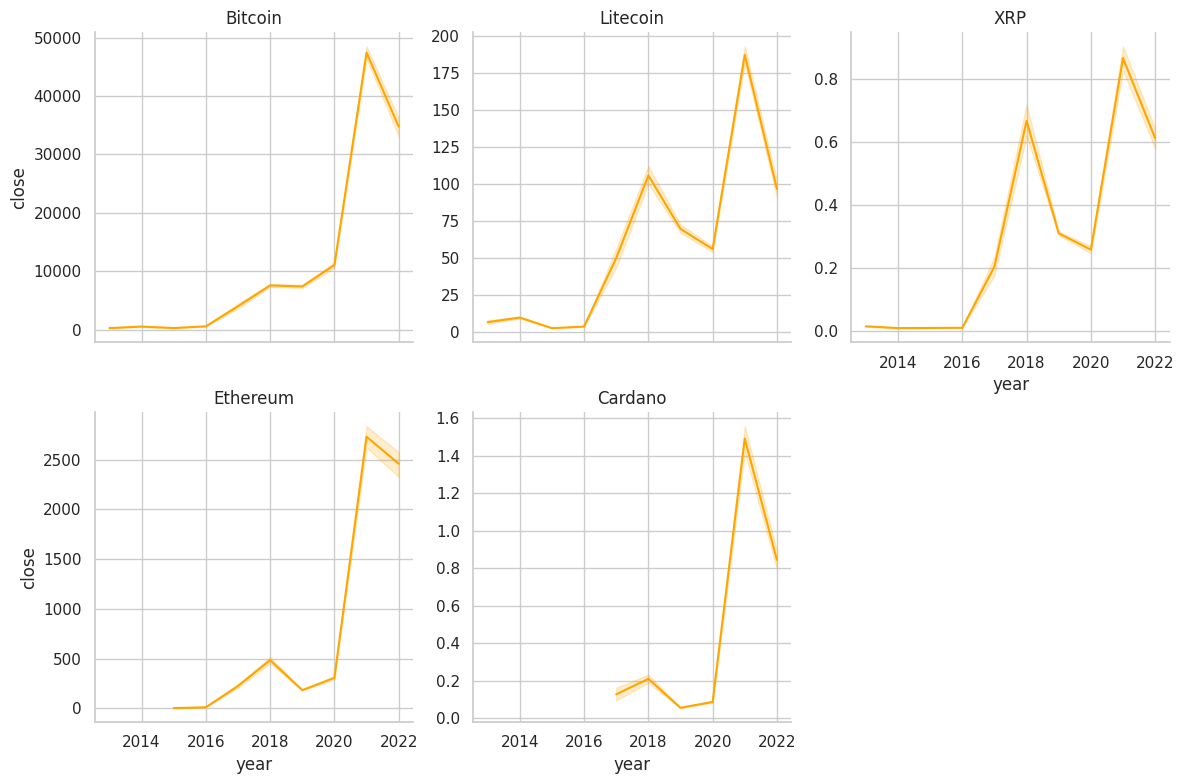

In [ ]:
selected_coins = ['Bitcoin', 'Ethereum', 'XRP', 'Cardano', 'Litecoin']
filtered_df = df[df['crypto_name'].isin(selected_coins)]

g = sns.FacetGrid(filtered_df, col="crypto_name", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "year", "close", color="orange")
g.set_titles("{col_name}")
plt.show()

##Outlier Detection

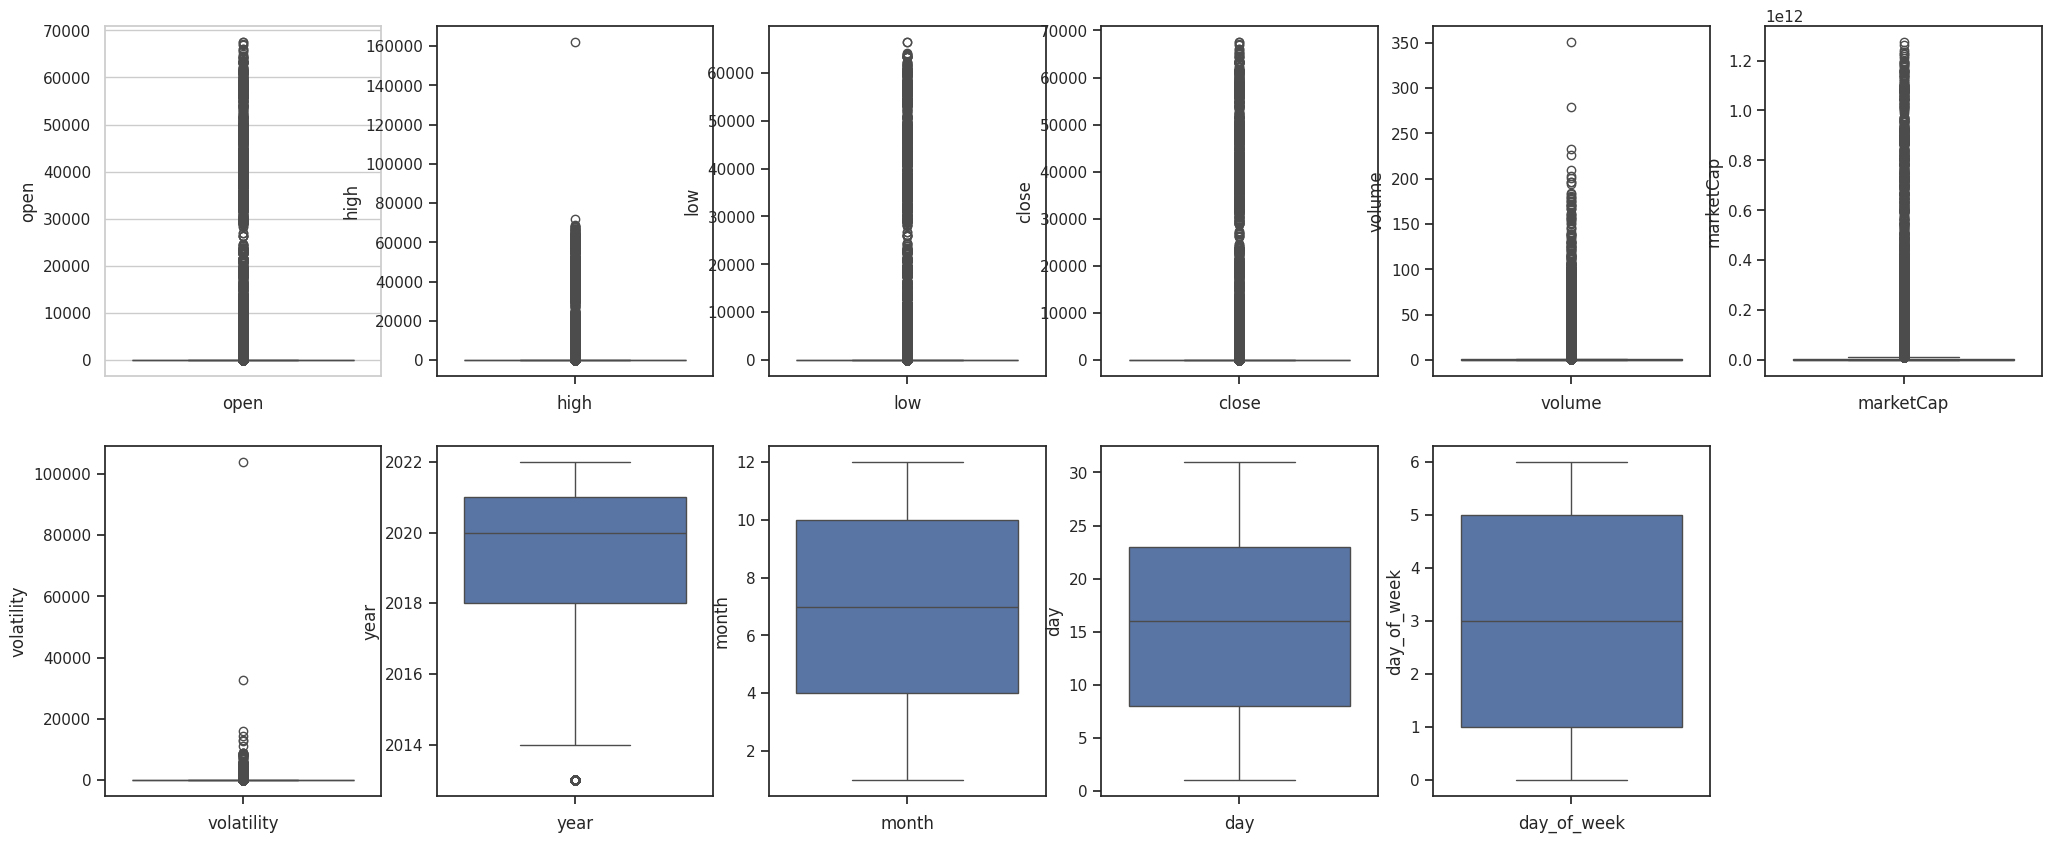

In [ ]:
cont_features = num_cols.copy()
plt.figure(figsize=(25, 10))

for i in range(len(cont_features)):
        plt.subplot(2,6,i+1)
        sns.set_style('ticks')
        plt.xlabel(cont_features[i])
        ax = sns.boxplot(df[cont_features[i]])

In [ ]:
def cap_outliers(df_input, columns):
    """Cap outliers using IQR method. Returns cleaned copy of dataframe."""
    df_cleaned = df_input.copy()

    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        print(f"\n#### {col} ####")
        print(f"  25th Percentile : {Q1:.4f}")
        print(f"  75th Percentile : {Q3:.4f}")
        print(f"  Lower Limit     : {lower_limit:.4f}")
        print(f"  Upper Limit     : {upper_limit:.4f}")

        df_cleaned.loc[df_cleaned[col] > upper_limit, col] = upper_limit
        df_cleaned.loc[df_cleaned[col] < lower_limit, col] = lower_limit

    return df_cleaned


In [ ]:
outlier_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'volatility']
df_cleaned = cap_outliers(df, outlier_cols)



 #### open ####
percentile25 0.17
percentile75 26.07
Upper limit 64.91999999999999
Lower limit -38.67999999999999

 #### high ####
percentile25 0.18
percentile75 27.5675
Upper limit 68.64874999999999
Lower limit -40.90125

 #### low ####
percentile25 0.16
percentile75 24.79
Upper limit 61.735
Lower limit -36.785000000000004

 #### close ####
percentile25 0.17
percentile75 26.25
Upper limit 65.37
Lower limit -38.949999999999996

 #### volume ####
percentile25 0.00832061759
percentile75 0.6691398474025
Upper limit 1.66036869212125
Lower limit -0.9829082271287499

 #### marketCap ####
percentile25 186043250.0
percentile75 5118618335.975
Upper limit 12517480964.9375
Lower limit -7212819378.962501

 #### volatility ####
percentile25 0.01
percentile75 2.1
Upper limit 5.235000000000001
Lower limit -3.125000000000001


In [ ]:
df_cleaned = df_cleaned.drop('crypto_name', axis=1)
df_cleaned.skew(axis=0, skipna=True, numeric_only=True)


,0
open,1.187330
high,1.190666
low,1.187154
close,1.189190
volume,1.193092
marketCap,1.193528
volatility,1.191355
year,-0.914920
month,-0.020600
day,0.005597


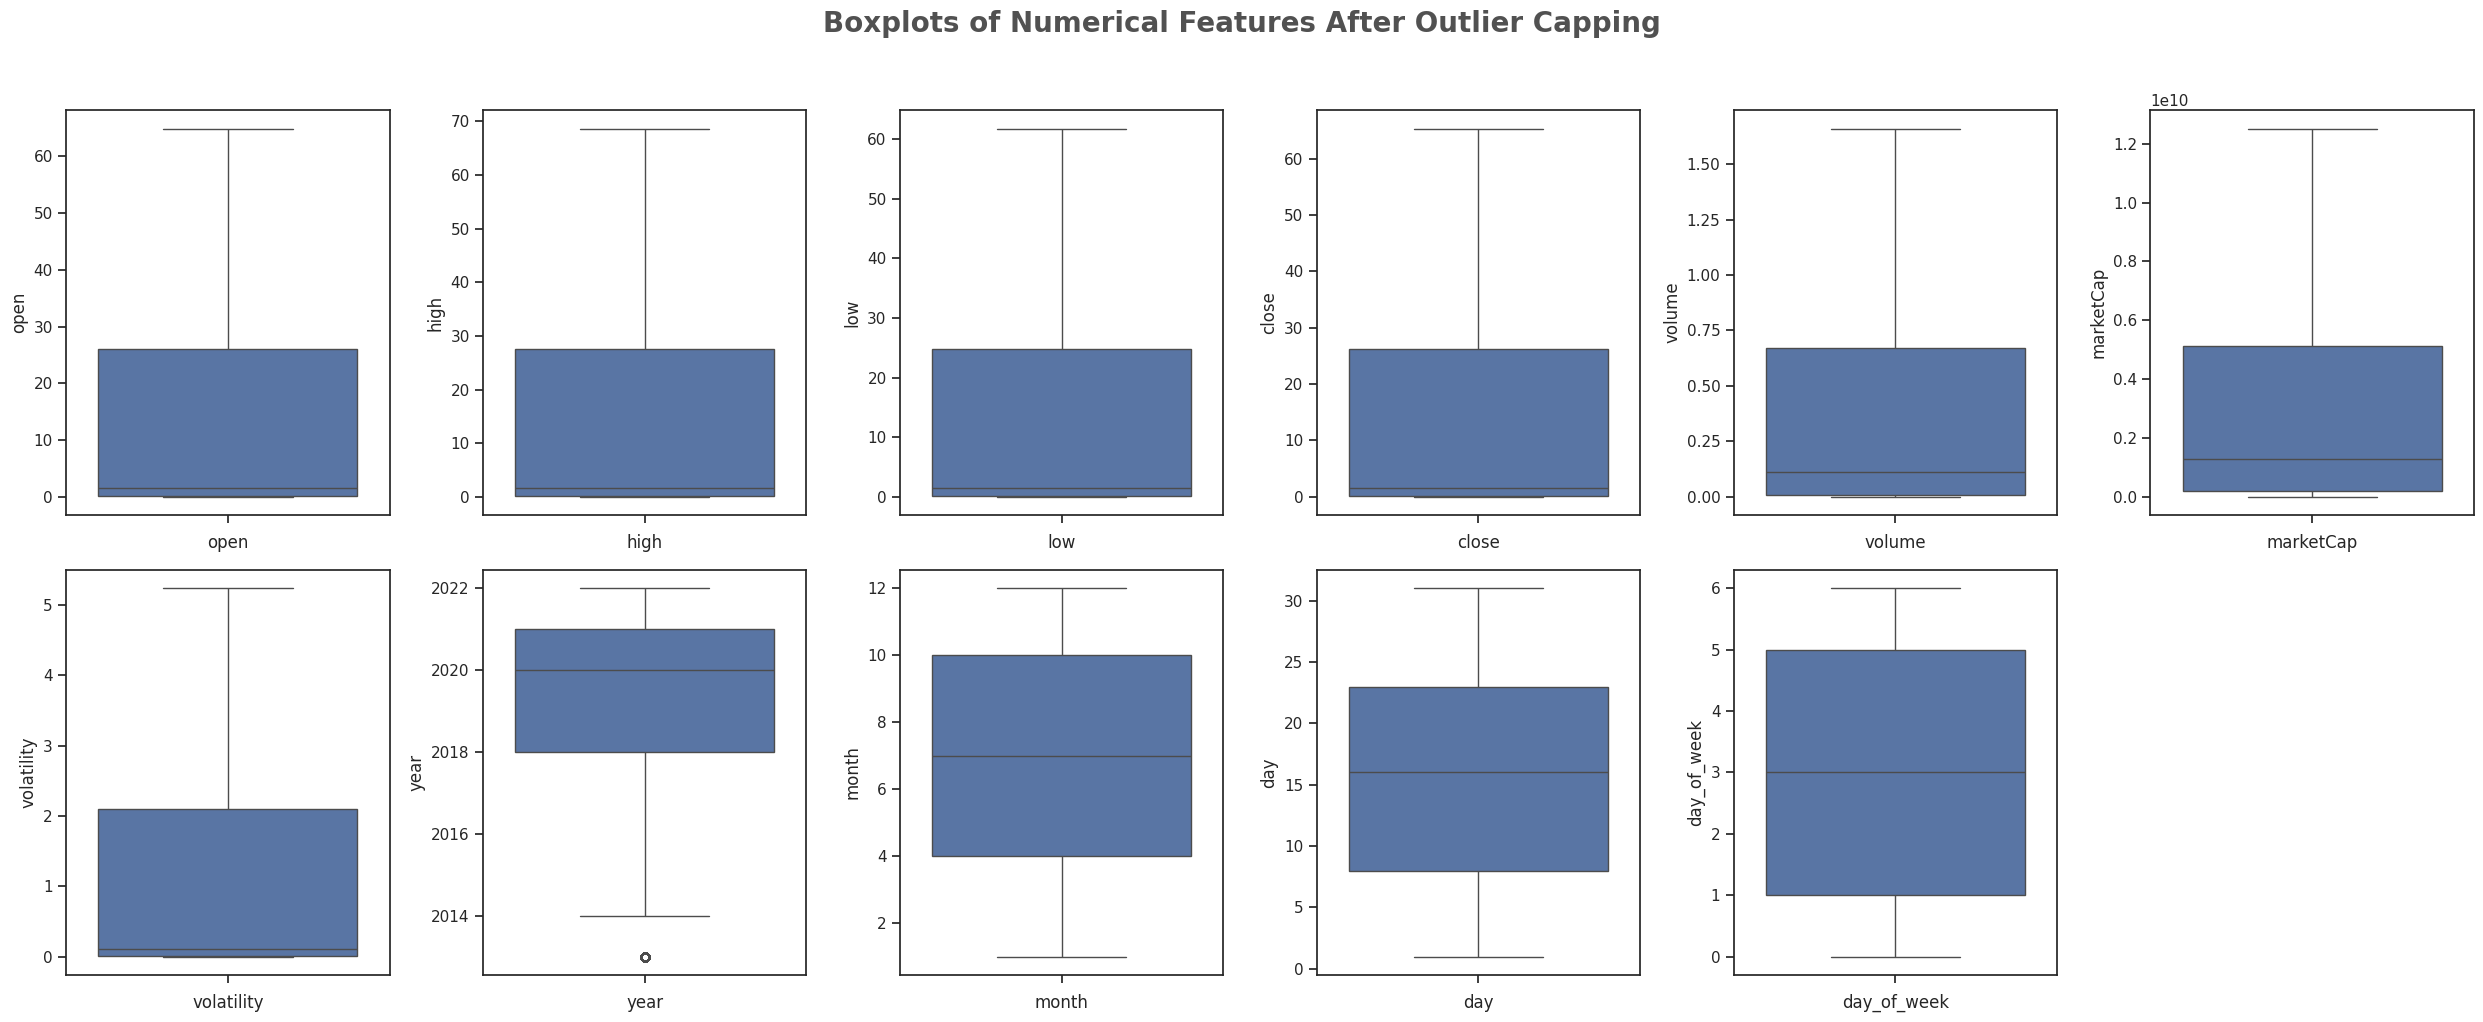

In [ ]:
plt.figure(figsize=(25, 10))
plt.suptitle('Boxplots of Numerical Features After Outlier Capping', fontsize=20, fontweight='bold', alpha=0.8, y=1.02)
for i, col_name in enumerate(df_cleaned.columns):
        plt.subplot(2,6,i+1)
        sns.set_style('ticks')
        plt.xlabel(col_name)
        ax = sns.boxplot(y=df_cleaned[col_name])
plt.tight_layout()
plt.show()

In [ ]:
# Update original df with cleaned numeric values (crypto_name column preserved)
df.update(df_cleaned)
print("Outlier capping applied. Shape:", df.shape)


In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# `dataC` is copied from `df` which includes 'crypto_name' at this point.
dataC = df.copy()

# Define columns for different transformations
power_transform_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'volatility']
standard_scale_only_cols = ['year', 'month', 'day', 'day_of_week']

# Pipeline for standard scaling (for temporal features)
numeric_pipeline = Pipeline(steps=[("Imputer", SimpleImputer(strategy='constant', fill_value=0)),("StandardScaler", StandardScaler())])

# Pipeline for power transformation (for skewed features) followed by standard scaling
outlier_features_pipeline = Pipeline(steps=[("Imputer", SimpleImputer(strategy='median')),("transformer", PowerTransformer(standardize=True))])

preprocessor = ColumnTransformer([("power_transform_pipeline", outlier_features_pipeline, power_transform_cols),("standard_scale_pipeline", numeric_pipeline, standard_scale_only_cols)],remainder='passthrough')

transformed_data = preprocessor.fit_transform(dataC)

# Construct new column names correctly based on the order of pipelines and remainder
final_scaled_column_names = power_transform_cols + standard_scale_only_cols + ['crypto_name']

scaled_data = pd.DataFrame(transformed_data, columns=final_scaled_column_names)
print("After scaling, let's have a glimpse of the scaled dataset :")
scaled_data

After scaling, let's have a glimpse of the scaled dataset :


,open,high,low,close,volume,marketCap,volatility,year,month,day,day_of_week,crypto_name
0,1.420673,1.419758,1.422434,1.421064,-1.009682,0.033326,1.542039,-3.054941,-0.444186,-1.218528,1.455142,Bitcoin
1,0.144943,0.154861,0.142792,0.159075,-1.009682,-1.071285,-0.025475,-3.054941,-0.444186,-1.218528,1.455142,Litecoin
2,1.420673,1.419758,1.422434,1.421064,-1.009682,0.018205,1.542039,-3.054941,-0.444186,-1.104872,-1.484113,Bitcoin
3,0.160227,0.167799,0.104021,0.124874,-1.009682,-1.087489,0.404704,-3.054941,-0.444186,-1.104872,-1.484113,Litecoin
4,1.420673,1.419758,1.422434,1.421064,-1.009682,0.014943,1.542039,-3.054941,-0.444186,-0.991217,-0.994237,Bitcoin
...,...,...,...,...,...,...,...,...,...,...,...,...
72941,-1.160327,-1.164028,-1.156588,-1.160383,-0.749372,0.157116,-0.899345,1.32268,1.00349,0.827273,1.455142,VeChain
72942,-0.31158,-0.307737,-0.305769,-0.295703,-0.822795,0.131914,-0.583735,1.32268,1.00349,0.827273,1.455142,Flow
72943,0.332761,0.332574,0.353907,0.349406,-0.3887,0.127641,-0.32812,1.32268,1.00349,0.827273,1.455142,Filecoin
72944,-1.182082,-1.185402,-1.178734,-1.182116,0.058713,0.133025,-0.899345,1.32268,1.00349,0.827273,1.455142,Terra Classic


In [ ]:
scaled_data = pd.get_dummies(scaled_data, columns=['crypto_name'], dtype=int)
scaled_data.head()


,open,high,low,close,volume,marketCap,volatility,year,month,day,day_of_week,crypto_name_Aave,crypto_name_Algorand,crypto_name_ApeCoin,crypto_name_Aptos,crypto_name_Avalanche,crypto_name_BNB,crypto_name_Basic Attention Token,crypto_name_Binance USD,crypto_name_Bitcoin,crypto_name_Bitcoin Cash,crypto_name_Cardano,crypto_name_Casper,crypto_name_Chain,crypto_name_Chainlink,crypto_name_Chiliz,crypto_name_Cosmos,crypto_name_Cronos,crypto_name_Dai,crypto_name_Decentraland,crypto_name_Dogecoin,crypto_name_EOS,crypto_name_Elrond,crypto_name_Ethereum,crypto_name_Ethereum Classic,crypto_name_FTX Token,crypto_name_Filecoin,crypto_name_Flow,crypto_name_Hedera,crypto_name_Huobi Token,crypto_name_Internet Computer,crypto_name_Litecoin,crypto_name_Maker,crypto_name_Monero,crypto_name_NEAR Protocol,crypto_name_OKB,crypto_name_Polkadot,crypto_name_Polygon,crypto_name_Quant,crypto_name_Ravencoin,crypto_name_Shiba Inu,crypto_name_Solana,crypto_name_Stellar,crypto_name_THORChain,crypto_name_TRON,crypto_name_Terra Classic,crypto_name_Tether,crypto_name_Tezos,crypto_name_The Sandbox,crypto_name_Theta Network,crypto_name_Toncoin,crypto_name_UNUS SED LEO,crypto_name_USD Coin,crypto_name_Uniswap,crypto_name_VeChain,crypto_name_Wrapped Bitcoin,crypto_name_XRP
0,1.420673,1.419758,1.422434,1.421064,-1.009682,0.033326,1.542039,-3.054941,-0.444186,-1.218528,1.455142,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.144943,0.154861,0.142792,0.159075,-1.009682,-1.071285,-0.025475,-3.054941,-0.444186,-1.218528,1.455142,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,1.420673,1.419758,1.422434,1.421064,-1.009682,0.018205,1.542039,-3.054941,-0.444186,-1.104872,-1.484113,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.160227,0.167799,0.104021,0.124874,-1.009682,-1.087489,0.404704,-3.054941,-0.444186,-1.104872,-1.484113,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.420673,1.419758,1.422434,1.421064,-1.009682,0.014943,1.542039,-3.054941,-0.444186,-0.991217,-0.994237,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
correlation_series = scaled_data.corr(numeric_only=True)['volatility'].sort_values(ascending=False)
print("Top 10 Features Correlated with Volatility:")
print(correlation_series.head(11))


Top 10 Features for Volatility:
volatility                  1.000000
high                        0.953291
close                       0.951212
open                        0.950793
low                         0.948485
marketCap                   0.408470
crypto_name_Bitcoin         0.329169
volume                      0.328246
crypto_name_Bitcoin Cash    0.237758
crypto_name_Maker           0.231064
crypto_name_Ethereum        0.217269
Name: volatility, dtype: float64


###Reports
- Except volatility top 4 columns shows almost same relation cause multicollinearity, So we took one from all of these as X.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

models = {
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Linear Regression": LinearRegression(),
     "K-Neighbors": KNeighborsRegressor(),
    "XGBRegressor": XGBRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [ ]:
def evaluate_models(X, y, models):
    """Train and evaluate multiple regression models. Returns performance report and trained models."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    models_list = []
    scores = []
    trained_models = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        MSE  = mean_squared_error(y_test, y_pred)
        RMSE = np.sqrt(MSE)
        MAE  = mean_absolute_error(y_test, y_pred)
        R2   = r2_score(y_test, y_pred)

        score = {"MSE": MSE, "RMSE": RMSE, "MAE": MAE, "R2": R2}
        print(f"---- {model_name} ----")
        print(f"  R2={R2:.4f} | RMSE={RMSE:.4f} | MAE={MAE:.4f}\n")

        models_list.append(model_name)
        scores.append(score)
        trained_models[model_name] = model

    report = pd.DataFrame({"Model": models_list, "Metrics": scores})
    return report, trained_models, X_train, X_test, y_train, y_test


In [ ]:
numerical_features = power_transform_cols + standard_scale_only_cols

for col in numerical_features:
    if col in scaled_data.columns:
        scaled_data[col] = pd.to_numeric(scaled_data[col], errors='coerce')

X = scaled_data.drop(columns=['volatility', 'high', 'close', 'low'])
y = scaled_data['volatility']
y = pd.to_numeric(y, errors='coerce')

report, trained_models, X_train, X_test, y_train, y_test = evaluate_models(X, y, models)


---- score for --- Random Forest ----
{'MSE': 0.018386238889144237, 'RMSE': np.float64(0.13559586604739923), 'MAE': 0.06806143729043727, 'R2': 0.9816562899497359}
---- score for --- Decision Tree ----
{'MSE': 0.03489053372457114, 'RMSE': np.float64(0.18679007929911895), 'MAE': 0.0909376326257285, 'R2': 0.9651901708663003}
---- score for --- Gradient Boosting ----
{'MSE': 0.03438714486297069, 'RMSE': np.float64(0.18543771154479524), 'MAE': 0.1036156721683863, 'R2': 0.9656923953492631}
---- score for --- Linear Regression ----
{'MSE': 0.04955859366996593, 'RMSE': np.float64(0.22261759514909402), 'MAE': 0.14899378011682698, 'R2': 0.9505560393149541}
---- score for --- K-Neighbors ----
{'MSE': 0.029231137364819547, 'RMSE': np.float64(0.1709711594533404), 'MAE': 0.08700048422617869, 'R2': 0.970836476590311}
---- score for --- XGBRegressor ----
{'MSE': 0.020123312490020778, 'RMSE': np.float64(0.14185666177526093), 'MAE': 0.07612806157184908, 'R2': 0.9799232343388213}
---- score for --- AdaBo

###Report
- Top Performer: Random Forest Regressor achieved the highest $R^2$ (0.9818) and the lowest MSE (0.0182), demonstrating its superior ability to handle non-linear relationships in crypto market data.

###Now Doing HyperParameterTuning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
param = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error']
}
grid_search = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [43]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import joblib

# Train best model with tuned hyperparameters
best_rf_model = RandomForestRegressor(
    criterion="squared_error",
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Random Forest Regressor (Tuned)")
print("R2 Score : {:.4f}".format(r2))
print("MAE      : {:.4f}".format(mae))

# Save model to disk
joblib.dump(best_rf_model, "best_crypto_model.pkl")
print("\n✅ Model saved as best_crypto_model.pkl")


Random Forest Regressor (Tuned)
R2 Score: 0.9816
MAE: 0.0694


In [ ]:
# ── Final Prediction Visualization ─────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.4, color="steelblue", edgecolors="k", linewidths=0.3)
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Fit")
axes[0].set_xlabel("Actual Volatility", fontsize=12)
axes[0].set_ylabel("Predicted Volatility", fontsize=12)
axes[0].set_title("Actual vs Predicted Volatility", fontsize=14, fontweight="bold")
axes[0].legend()

# Residuals distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (Actual - Predicted)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Residual Distribution", fontsize=14, fontweight="bold")

plt.suptitle("Model Evaluation: Random Forest Regressor (Tuned)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("   CRYPTO VOLATILITY PREDICTION — PROJECT COMPLETE")
print("="*60)
print(f"   Best Model   : Random Forest Regressor (Tuned)")
print(f"   R² Score     : {r2:.4f}")
print(f"   MAE          : {mae:.4f}")
print(f"   Model File   : best_crypto_model.pkl")
print("="*60)
